In [1]:
from google.colab import files

# Open file picker and upload
uploaded = files.upload()

Saving spam.csv to spam.csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/tmp/ipykernel_410/4031666730.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['label'].map({0: 'Ham (Valid)', 1: 'Spam'}), ax=axes[0], palette='viridis')


📁 Loading data from 'spam.csv'...
📊 Generating Dataset Distribution Charts...


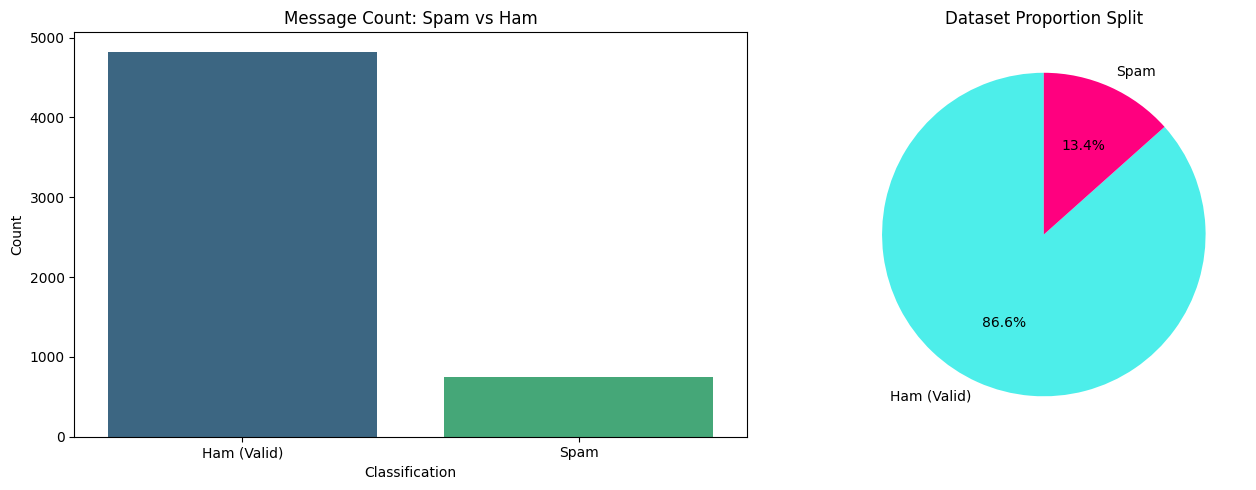

🧼 Preprocessing and cleaning text tokens...
🤖 Training Multinomial Naïve Bayes Model...

📈 PERFORMANCE METRICS
Accuracy:  96.41%
Precision: 99.10%
Recall:    73.83%
F1-Score:  84.62%


/tmp/ipykernel_410/4031666730.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_names, y=metrics_values, ax=axes[1], palette='magma')


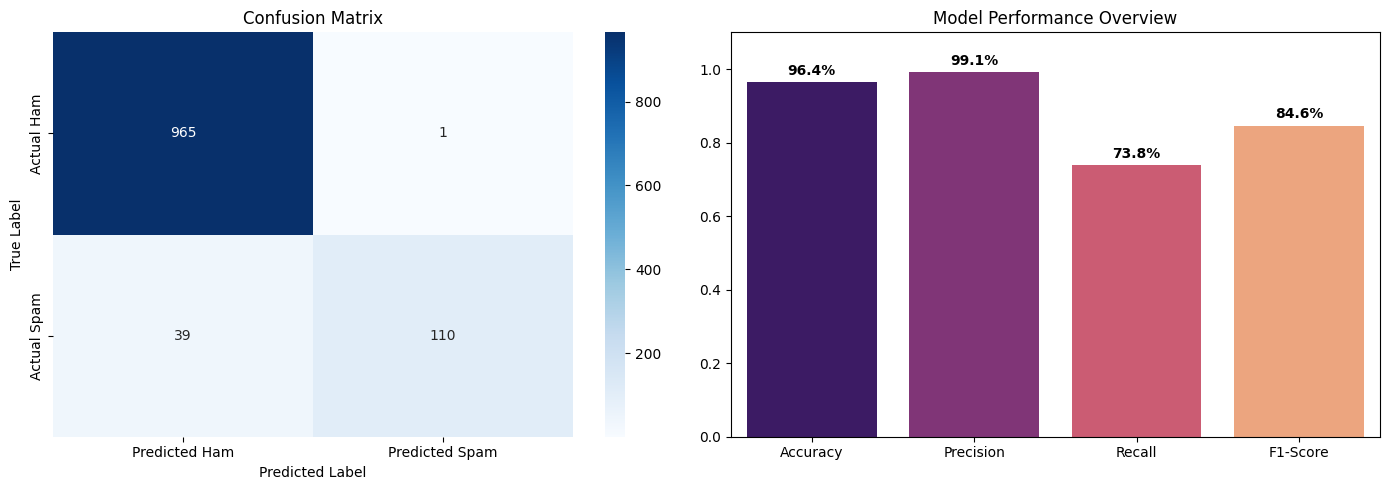


--- Live Production Scan ---
Type any text below to scan it for spam. Type 'exit' to terminate.

Enter message text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
----------------------------------------
🚨 ALERT: Classified as SPAM
----------------------------------------
Enter message text: exit
Shutting down model interface. Goodbye!


In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ensure NLTK resources are available
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

# =====================================================================
# 1. TEXT CLEANING PIPELINE
# =====================================================================
def clean_text(text):
    """Removes punctuation, lowers case, removes stop words, and stems."""
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    words = text.split()
    stop_words = set(stopwords.words('english'))
    stemmer = PorterStemmer()
    cleaned_words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(cleaned_words)

# =====================================================================
# 2. LOAD REAL CSV DATA
# =====================================================================
csv_filename = 'spam.csv'

if not os.path.exists(csv_filename):
    raise FileNotFoundError(f"❌ '{csv_filename}' not found! Please place the real Kaggle/UCI CSV in this directory.")

print(f"📁 Loading data from '{csv_filename}'...")
# Handling standard Kaggle Latin-1 formatting issues
df = pd.read_csv(csv_filename, encoding='latin-1')

# Clean up columns if they match standard Kaggle 'v1'/'v2' format
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']]
    df.columns = ['label', 'text']

# Validate dataset columns
if 'label' not in df.columns or 'text' not in df.columns:
    raise ValueError("CSV must contain 'label' and 'text' columns (or v1 and v2 standard format).")

# Clean labels: map 'ham' to 0 and 'spam' to 1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# =====================================================================
# 3. DATA VISUALIZATION (Countplot & Pie Chart)
# =====================================================================
print("📊 Generating Dataset Distribution Charts...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
sns.countplot(x=df['label'].map({0: 'Ham (Valid)', 1: 'Spam'}), ax=axes[0], palette='viridis')
axes[0].set_title('Message Count: Spam vs Ham')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Classification')

# Pie Chart
label_counts = df['label'].value_counts()
axes[1].pie(label_counts, labels=['Ham (Valid)', 'Spam'], autopct='%1.1f%%', startangle=90, colors=['#4deeea', '#ff007f'])
axes[1].set_title('Dataset Proportion Split')

plt.tight_layout()
plt.show()

# =====================================================================
# 4. TRAINING THE MODEL
# =====================================================================
print("🧼 Preprocessing and cleaning text tokens...")
df['cleaned_text'] = df['text'].apply(clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("🤖 Training Multinomial Naïve Bayes Model...")
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# =====================================================================
# 5. METRICS & PERFORMANCE VISUALIZATIONS
# =====================================================================
y_pred = model.predict(X_test_vec)

# Calculations
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*40)
print("📈 PERFORMANCE METRICS")
print("="*40)
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print("="*40)

# Render Confusion Matrix & Metric Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
sns.barplot(x=metrics_names, y=metrics_values, ax=axes[1], palette='magma')
axes[1].set_title('Model Performance Overview')
axes[1].set_ylim(0, 1.1)
for i, v in enumerate(metrics_values):
    axes[1].text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# =====================================================================
# 6. INTERACTIVE DEPLOYMENT INTERFACE
# =====================================================================
print("\n--- Live Production Scan ---")
print("Type any text below to scan it for spam. Type 'exit' to terminate.\n")

while True:
    user_msg = input("Enter message text: ").strip()
    if user_msg.lower() in ['exit', 'quit']:
        print("Shutting down model interface. Goodbye!")
        break
    if not user_msg:
        continue

    processed_msg = clean_text(user_msg)
    vectorized_msg = vectorizer.transform([processed_msg])
    prediction = model.predict(vectorized_msg)[0]

    print("-" * 40)
    if prediction == 1:
        print("🚨 ALERT: Classified as SPAM")
    else:
        print("✅ SAFE: Classified as HAM (Legitimate)")
    print("-" * 40)